In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
import pyarrow.parquet as pq

# Load parquet file
parquet_file = "processedData/cicandmal2020-static.parquet"  # Replace with your actual parquet filename
df = pq.read_table(parquet_file).to_pandas()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

Dataset shape: (357805, 9505)
Columns: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70', 'F71', 'F72', 'F73', 'F74', 'F75', 'F76', 'F77', 'F78', 'F79', 'F80', 'F81', 'F82', 'F83', 'F84', 'F85', 'F86', 'F87', 'F88', 'F89', 'F90', 'F91', 'F92', 'F93', 'F94', 'F95', 'F96', 'F97', 'F98', 'F99', 'F100', 'F101', 'F102', 'F103', 'F104', 'F105', 'F106', 'F107', 'F108', 'F109', 'F110', 'F111', 'F112', 'F113', 'F114', 'F115', 'F116', 'F117', 'F118', 'F119', 'F120', 'F121', 'F122', 'F123', 'F124', 'F125', 'F126', 'F127', 'F128', 'F129', 'F130', 'F131', 'F132', 'F133'

In [18]:
"""

# Updated Label Mapping
label_map = {
    'benign': 0, 'adware': 1, 'backdoor': 2, 'banker': 3, 'dropper': 4,
    'fileinjector': 5, 'NoCategory': 6, 'PUA': 7, 'Ransomware': 8,
    'Riskware': 9, 'SMS': 10, 'Scareware': 11, 'Spy': 12, 'Trojan': 13, 'Zeroday': 14
}

# Load datasets (Replace 'malware_multiclass.csv' with your actual multiclass filename)
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_multiclass.csv") 

# Reset columns to ensure consistency before concatenation
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])

# Concatenate datasets
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

# Ensure feature 9504 contains the integer values 0-14 according to label_map
print("Value counts for multiclass labels:")
print(df[9504].value_counts())
"""

'\n\n# Updated Label Mapping\nlabel_map = {\n    \'benign\': 0, \'adware\': 1, \'backdoor\': 2, \'banker\': 3, \'dropper\': 4,\n    \'fileinjector\': 5, \'NoCategory\': 6, \'PUA\': 7, \'Ransomware\': 8,\n    \'Riskware\': 9, \'SMS\': 10, \'Scareware\': 11, \'Spy\': 12, \'Trojan\': 13, \'Zeroday\': 14\n}\n\n# Load datasets (Replace \'malware_multiclass.csv\' with your actual multiclass filename)\nbenign_df = pd.read_csv("processedData/benign.csv")\nmal_df = pd.read_csv("processedData/malware_multiclass.csv") \n\n# Reset columns to ensure consistency before concatenation\nbenign_df.columns = range(benign_df.shape[1])\nmal_df.columns = range(mal_df.shape[1])\n\n# Concatenate datasets\ndf = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)\n\n# Ensure feature 9504 contains the integer values 0-14 according to label_map\nprint("Value counts for multiclass labels:")\nprint(df[9504].value_counts())\n'

In [19]:
# Convert label column to numeric values using label_map
label_map = {
	'benign': 0, 'adware': 1, 'backdoor': 2, 'banker': 3, 'dropper': 4
}

df['Label'] = df['Label'].str.lower().map(label_map)

print("Label conversion complete")
print(df['Label'].value_counts().sort_index())

Label conversion complete
Label
0.0    162181
1.0     47210
2.0      1538
3.0       887
4.0      2302
Name: count, dtype: int64


In [20]:

X = df.drop('Label', axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df['Label']

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


F3335    0.600194
F37      0.591437
F50      0.589287
F48      0.573773
F3052    0.510414
F63      0.510414
F57      0.501930
F3293    0.478581
F107     0.458452
F58      0.455936
F51      0.446939
F25      0.445880
F66      0.445572
F3282    0.442089
F36      0.440499
F26      0.431377
F60      0.413081
F106     0.393231
F119     0.392821
F59      0.391265
dtype: float64


In [21]:
"""
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns)
top_features = mi_scores.sort_values(ascending=False).head(50)
"""

'\nfrom sklearn.feature_selection import mutual_info_classif\n\nmi = mutual_info_classif(X, y)\n\nmi_scores = pd.Series(mi, index=X.columns)\ntop_features = mi_scores.sort_values(ascending=False).head(50)\n'

In [22]:
TOP_N = 20

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: ['F3335', 'F37', 'F50', 'F48', 'F3052', 'F63', 'F57', 'F3293', 'F107', 'F58', 'F51', 'F25', 'F66', 'F3282', 'F36', 'F26', 'F60', 'F106', 'F119', 'F59']


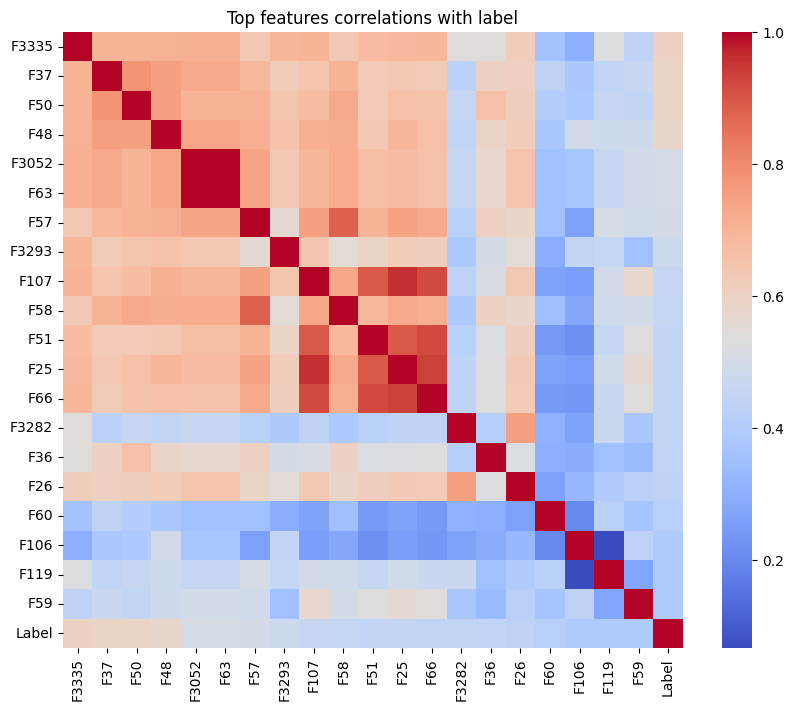

In [23]:


#top_features = mi_scores.sort_values(ascending=False).head(20).index
corr_matrix = df[top_features + ['Label']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top features correlations with label")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Remove rows with NaN labels
valid_indices = y.notna()
X_reduced = X[top_features][valid_indices]
y_clean = y[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=42
)

#model - RandomForestClassifier with hyperparameters tuned for multiclass classification
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
inv_label_map = {v: k for k, v in label_map.items()}
target_names = [inv_label_map[i] for i in sorted(inv_label_map.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))

Multiclass Accuracy: 0.9271203063702597

Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.94      0.96     32437
      adware       0.91      0.90      0.90      9442
    backdoor       0.23      0.69      0.34       308
      banker       0.39      0.56      0.46       177
     dropper       0.36      0.73      0.49       460

    accuracy                           0.93     42824
   macro avg       0.57      0.76      0.63     42824
weighted avg       0.95      0.93      0.93     42824



In [26]:
#cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_reduced, y_clean, cv=5)
print(scores.mean())

0.9265405001962229


In [27]:
# Detailed classification report with target names

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      benign       0.97      0.94      0.96     32437
      adware       0.91      0.90      0.90      9442
    backdoor       0.23      0.69      0.34       308
      banker       0.39      0.56      0.46       177
     dropper       0.36      0.73      0.49       460

    accuracy                           0.93     42824
   macro avg       0.57      0.76      0.63     42824
weighted avg       0.95      0.93      0.93     42824



In [29]:
import shap
from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, # Limited depth for faster SHAP calculation
    random_state=42, 
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

# 2. Initialize the Explainer
# TreeExplainer is optimized specifically for Random Forests
explainer = shap.TreeExplainer(rf_shap)

# 3. Generate SHAP values for a sample
# We use a sample because calculating SHAP for the whole test set is slow
X_sample = X_test.sample(500)
shap_explanations = explainer(X_sample)
shap_values = shap_explanations.values

Generating Detailed Beeswarm for Class 0...


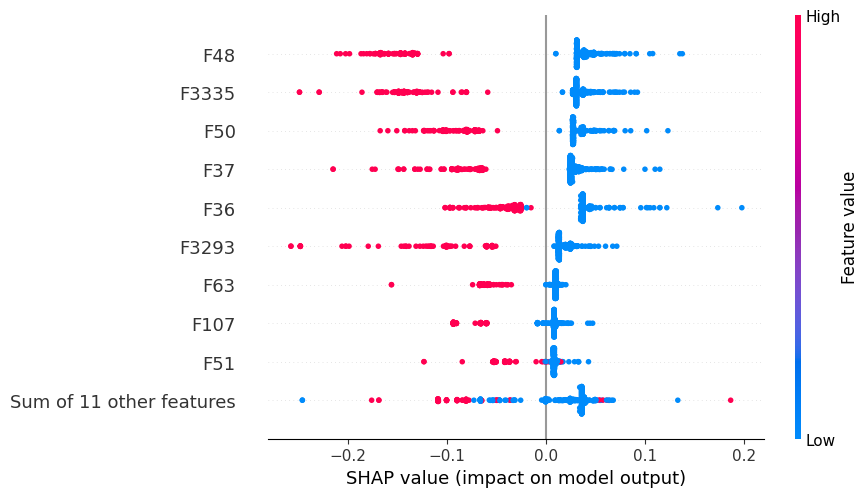

In [30]:
target_class_index = 0
print(f"Generating Detailed Beeswarm for Class {target_class_index}...")
shap.plots.beeswarm(shap_explanations[:, :, target_class_index])

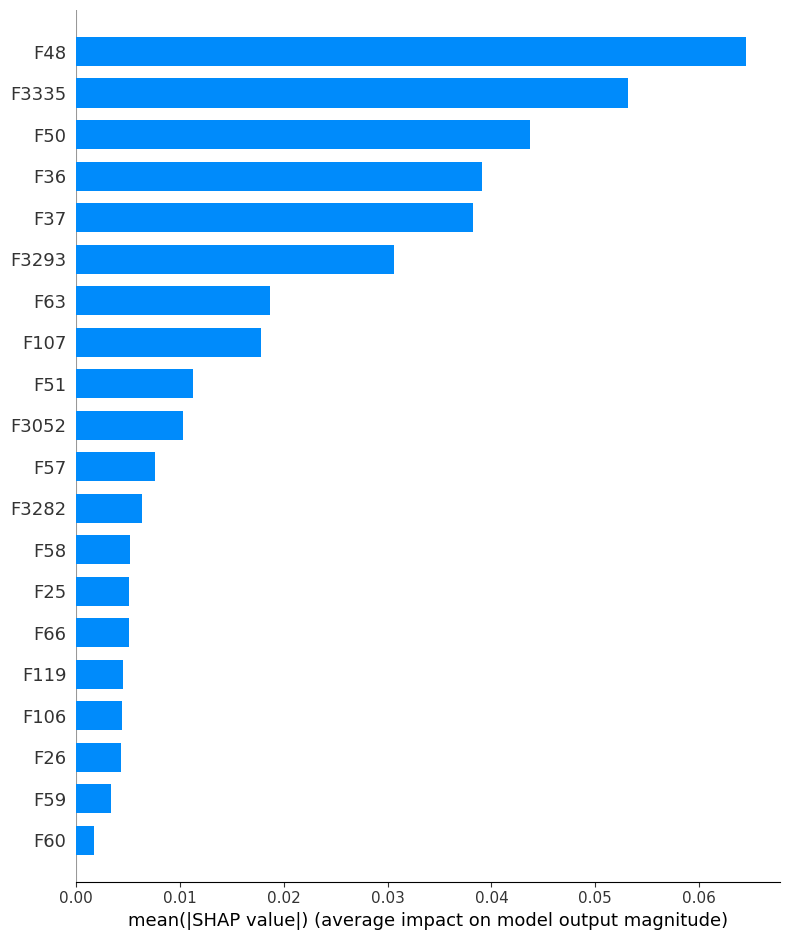

In [31]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

Generating explanation for Class: benign (Index 0)


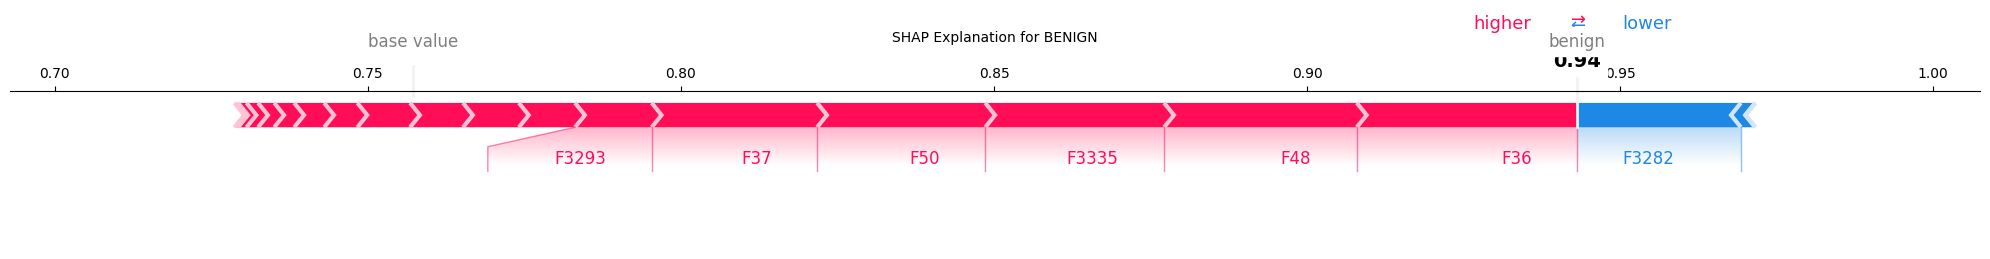

Generating explanation for Class: adware (Index 1)


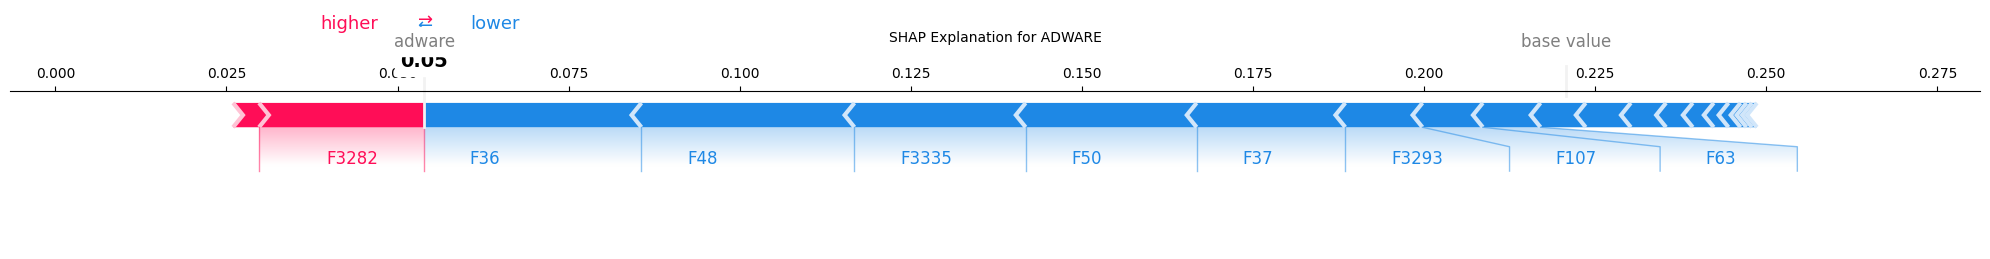

Generating explanation for Class: backdoor (Index 2)


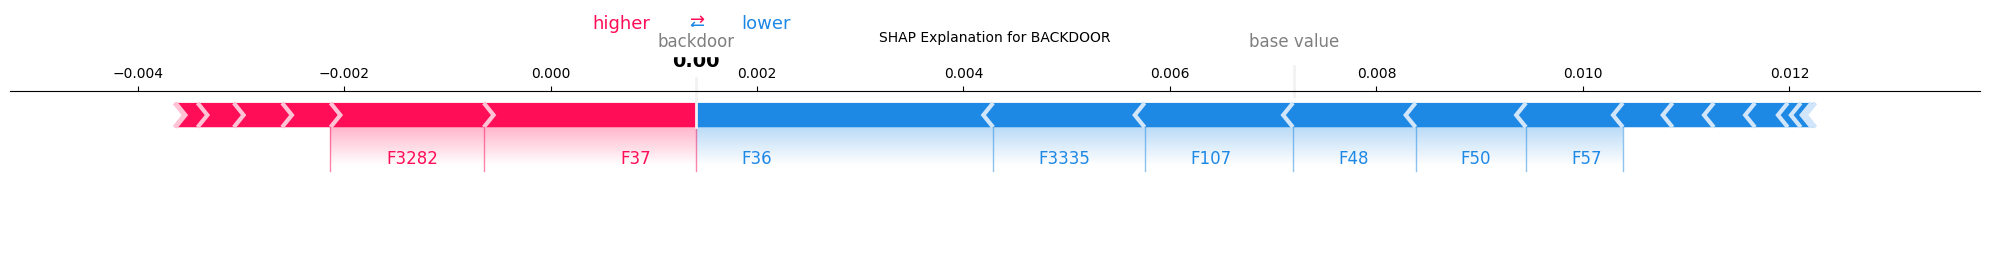

Generating explanation for Class: banker (Index 3)


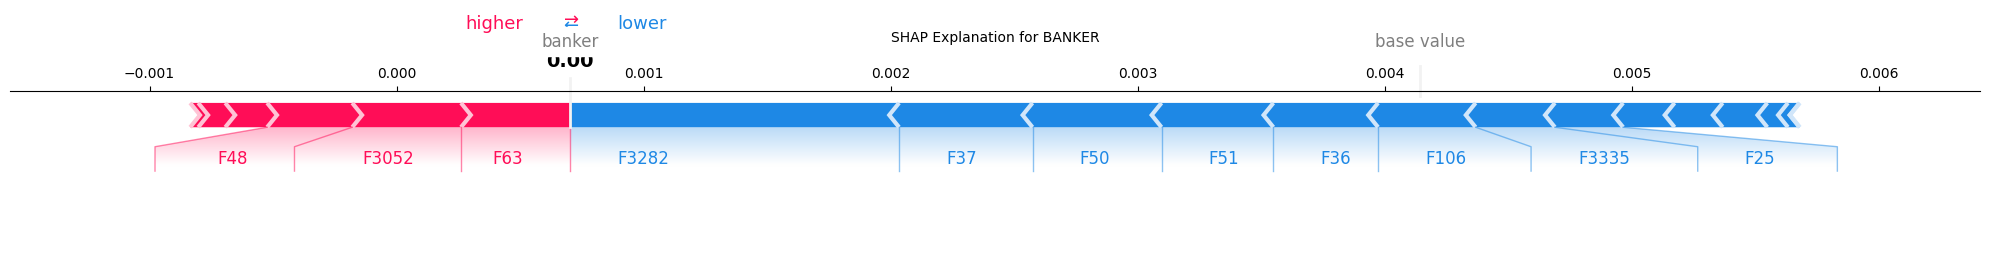

Generating explanation for Class: dropper (Index 4)


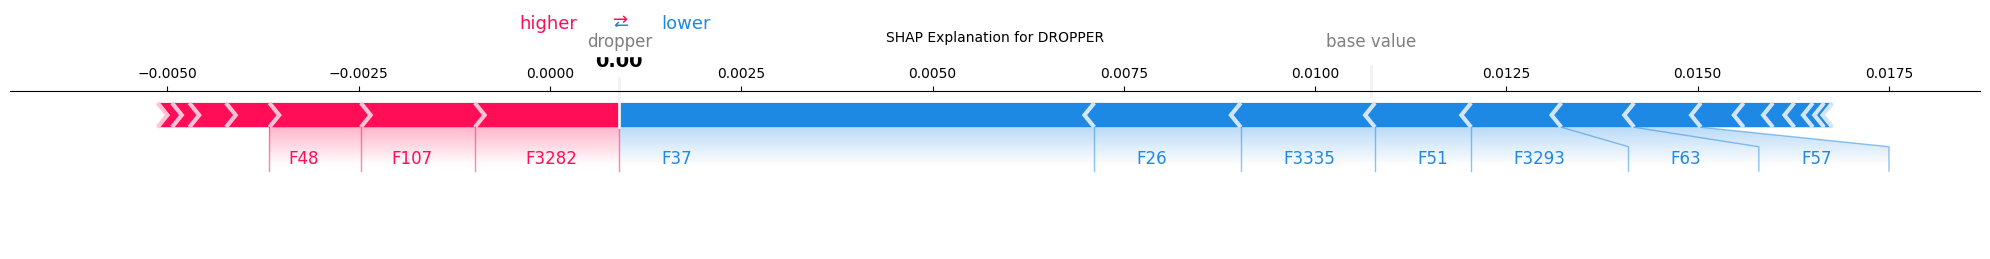

In [32]:
inv_label_map = {v: k for k, v in label_map.items()}



# 2. Select the app and the class you want to explain
i = 0  # Index of the Android app in X_sample


for idx in range(len(inv_label_map)): 
 target_class_index = idx # Example: Explain why it might be 'adware'

# 3. Prepare data for the plot
# Using .astype(float) prevents the UFuncTypeError by ensuring numbers aren't objects
 features_row = X_sample.iloc[i, :]
 feature_names = X_sample.columns.tolist()
 features_display = [str(val) for val in features_row.values]
 class_name = inv_label_map[target_class_index]

# 4. Generate the Force Plot
 print(f"Generating explanation for Class: {class_name} (Index {target_class_index})")

 shap.force_plot(
    float(explainer.expected_value[target_class_index]), 
    shap_values[i, :, target_class_index], 
    features_display,
    feature_names=feature_names,
    out_names=class_name, # This labels the final value as the specific malware type
    matplotlib=True,
    show=False
 )

# 5. Clean up the title and layout
 plt.title(f"SHAP Explanation for {class_name.upper()}", fontsize=10, pad=18)
 plt.tight_layout()
 plt.show()


In [34]:
sample = X_test.sample(n=100, random_state=42).reset_index(drop=True)
pred = model.predict(sample)

# 1. Setup the explainer and explanations
explainer_model = shap.TreeExplainer(model)
# Note: For some RF versions, you might need to use shap_values = explainer.shap_values(sample)
# but the standard explainer call is usually preferred:
shap_explanations_model = explainer_model(sample, check_additivity=False)

# Inverse label map to show names instead of numbers
inv_label_map = {v: k for k, v in label_map.items()}

# 2. Iterate through the predictions
for i, app_pred_idx in enumerate(pred):
    # Convert to integer for indexing
    app_pred_idx = int(app_pred_idx)
    
    # Get the human-readable name of the predicted class
    predicted_class_name = inv_label_map[app_pred_idx]
    
    # DYNAMIC INDEXING: 
    # Get the SHAP values for the specific class that was PREDICTED
    # shap_explanations_model.values shape is (samples, features, classes)
    current_shap_values = shap_explanations_model.values[i, :, app_pred_idx]
    feature_names = sample.columns
    
    # Sort features by their impact (top 3)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        
        # If SHAP is positive, it increased the probability of this class
        # If SHAP is negative, it decreased the probability
        if val > 0:
            direction = f"increased evidence for {predicted_class_name}"
        else:
            direction = f"decreased evidence for {predicted_class_name}"
            
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})")
        
    print(f"App {i}: Predicted as [{predicted_class_name.upper()}]")
    print(f"   Top Reasons: {', '.join(reasons)}\n")

App 0: Predicted as [BENIGN]
   Top Reasons: F37 (increased evidence for benign by 0.2164), F36 (increased evidence for benign by 0.1328), F26 (increased evidence for benign by 0.0914)

App 1: Predicted as [ADWARE]
   Top Reasons: F106 (increased evidence for adware by 0.1106), F63 (increased evidence for adware by 0.1074), F3052 (increased evidence for adware by 0.0928)

App 2: Predicted as [BENIGN]
   Top Reasons: F36 (increased evidence for benign by 0.1597), F37 (increased evidence for benign by 0.0673), F3293 (increased evidence for benign by 0.0559)

App 3: Predicted as [BENIGN]
   Top Reasons: F36 (increased evidence for benign by 0.0617), F3335 (increased evidence for benign by 0.0348), F50 (increased evidence for benign by 0.0347)

App 4: Predicted as [BENIGN]
   Top Reasons: F37 (increased evidence for benign by 0.1152), F26 (increased evidence for benign by 0.0895), F36 (decreased evidence for benign by 0.0778)

App 5: Predicted as [BENIGN]
   Top Reasons: F36 (increased evi

In [ ]:
from xgboost import XGBClassifier

modelx = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    tree_method="hist",
    n_jobs=-1
)

modelx.fit(X_train, y_train)

# Evaluation
y_pred = modelx.predict(X_test)
target_names = [label_map[i] for i in sorted(label_map.keys())]

print("Multiclass Accuracy:", modelx.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))